# Assignment 3 — Make it shippable

This notebook builds directly on the winning architecture from Assignment 2 v2: the **Reflex LangGraph**, which beat the HF-backed hybrid graph on accuracy, cost per alert, and wall time. The reflex classifier (`keyword_assess`) emits a label *and* a confidence score for every classification, so calibration, the escalation threshold, and confidence-based routing all still apply here even though there is no LLM in the loop — the requirement is about the classification step, not the specific model behind it.

What this notebook adds on top of the Assignment 2 reflex graph:
1. **Calibration** — measure whether the classifier's confidence means anything (ECE on 50 labelled alerts), recalibrate if not.
2. **Escalation threshold `p*`** — derived from the actual cost matrix, wired into a conditional edge so low-confidence alerts route to a human instead of the automated policy.
3. **The gate** — `interrupt()` before every `rollback`, with an evidence-only payload (no rationale).
4. **Memory** — per-service outcome history that raises the bar for rollback when a service has "cried wolf" before.
5. **The harness** — an iteration cap, a token budget, and a wall-clock limit, with a stress test that trips at least two of them and logs the stop reason.
6. **Evaluation** — accuracy, cost per alert, and a 95% confidence interval on the held-out 100 alerts (`alerts[100:200]`), never used for tuning.
7. **Failure taxonomy** — every failure from the held-out run, categorized and counted.

The final cell is the one honest paragraph the assignment says carries the most credit.

## 0. Setup

In [1]:
import os
import json
import time
import math
from collections import Counter, defaultdict
from dataclasses import dataclass, field
from typing import Any, TypedDict

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from alertgen import generate_alerts, Tools, score, COST

from langgraph.graph import StateGraph, START, END
from langgraph.types import interrupt, Command
from langgraph.checkpoint.memory import MemorySaver

SEED = 0
plt.style.use('seaborn-v0_8-whitegrid')
print('Setup complete.')

Setup complete.


## 1. Data split

200 alerts are generated once. The first 100 (`alerts_dev`) are used for every tuning decision: 50 of them (`alerts_calib`) for the calibration measurement, and the full 100 for deriving the escalation threshold and shaking out the harness. The last 100 (`alerts_holdout`) are touched only once, in the evaluation section, and are never used to make a tuning decision.

In [2]:
alerts_all = generate_alerts(200, seed=SEED)
alerts_dev = alerts_all[:100]
alerts_calib = alerts_all[:50]
alerts_holdout = alerts_all[100:200]

assert len(alerts_all) == 200
assert len(alerts_dev) == 100 and len(alerts_calib) == 50 and len(alerts_holdout) == 100
dev_ids = {a['alert_id'] for a in alerts_dev}
holdout_ids = {a['alert_id'] for a in alerts_holdout}
assert not (dev_ids & holdout_ids), 'Dev and holdout sets must not overlap.'

print(f'alerts_calib: {len(alerts_calib)} (subset of dev, used only for calibration)')
print(f'alerts_dev:   {len(alerts_dev)} (used for threshold derivation + harness tuning)')
print(f'alerts_holdout: {len(alerts_holdout)} (touched only in the final evaluation)')

alerts_calib: 50 (subset of dev, used only for calibration)
alerts_dev:   100 (used for threshold derivation + harness tuning)
alerts_holdout: 100 (touched only in the final evaluation)


## 2. Reused building blocks: tools, state, classifier, action policy

These are unchanged from Assignment 2 v2's Reflex LangGraph: an instrumented tool wrapper (so tool calls are always tracked from the real object), the retry helper, the keyword classifier (which is the thing being calibrated below), and the cost-aware action policy.

In [3]:
class TriageState(TypedDict, total=False):
    alert_id: str
    service: str
    logs: list[str]
    error_rate: dict[str, float] | None
    deploy: dict[str, Any] | None
    log_class: str
    confidence: float
    confidence_calibrated: float
    memory_flag: bool
    action: str
    human_overridden: bool
    route_reason: str
    tool_errors: list[str]


class InstrumentedTools:
    """Wraps Tools and records every call so counts are never read from an unused instance."""
    def __init__(self, alerts, seed=0, flaky=0.10):
        self.base = Tools(alerts, seed=seed, flaky=flaky)
        self.call_events = []

    def _record(self, name, ok, **payload):
        self.call_events.append({'tool': name, 'ok': ok, 'timestamp': time.time(), **payload})

    def read_logs(self, alert_id, n=6):
        try:
            result = self.base.read_logs(alert_id, n=n)
            self._record('read_logs', True, alert_id=alert_id)
            return result
        except Exception as exc:
            self._record('read_logs', False, alert_id=alert_id, error=type(exc).__name__)
            raise

    def deploy_history(self, alert_id):
        try:
            result = self.base.deploy_history(alert_id)
            self._record('deploy_history', True, alert_id=alert_id)
            return result
        except Exception as exc:
            self._record('deploy_history', False, alert_id=alert_id, error=type(exc).__name__)
            raise

    def error_rate(self, alert_id):
        try:
            result = self.base.error_rate(alert_id)
            self._record('error_rate', True, alert_id=alert_id)
            return result
        except Exception as exc:
            self._record('error_rate', False, alert_id=alert_id, error=type(exc).__name__)
            raise

    @property
    def total_calls(self):
        return len(self.call_events)

    @property
    def calls_by_tool(self):
        return dict(Counter(e['tool'] for e in self.call_events))


def call_with_retry(fn, *args, retries=1, errors=None, **kwargs):
    for attempt in range(retries + 1):
        try:
            return fn(*args, **kwargs)
        except TimeoutError:
            if errors is not None:
                errors.append(f'{fn.__name__} timeout on attempt {attempt + 1}')
    return None


def keyword_assess(logs):
    """The classifier being calibrated: returns (label, raw_confidence)."""
    text = ' '.join(logs).lower()
    if any(k in text for k in ('nullpointer', 'schema mismatch', 'deserialize', 'unhandled exception')):
        return 'bad_deploy', 0.95
    if any(k in text for k in ('connection refused', 'dns resolution', 'tls handshake', 'returned 503')):
        return 'dependency', 0.95
    if any(k in text for k in ('upstream', 'retry budget', 'thread pool', 'circuit breaker')):
        return 'degraded', 0.85
    return 'noise', 0.80


def action_from_evidence(state):
    er = state.get('error_rate')
    if er is None or er['current'] / er['baseline_7d'] < 3.0:
        return 'ignore'
    if state.get('log_class') == 'bad_deploy' and state.get('deploy') is not None and state['deploy']['minutes_since_deploy'] <= 25:
        return 'rollback'
    return 'escalate'

## 3. Calibration — does the classifier's confidence mean anything?

`keyword_assess` emits one of three fixed confidence values (0.95, 0.85, 0.80) depending on which keyword branch matched. We classify all 50 `alerts_calib` alerts directly against their true logs (bypassing tool flakiness, since this is a property of the classifier, not the tool layer), then measure the Expected Calibration Error (ECE): for each distinct confidence value, compare the *claimed* confidence to the *empirical* accuracy of predictions made at that confidence.

In [4]:
def compute_ece(records):
    """records: list of {'confidence': float, 'correct': bool}. Bins by the classifier's discrete confidence values."""
    total = len(records)
    bins = sorted(set(r['confidence'] for r in records))
    rows = []
    ece = 0.0
    for b in bins:
        group = [r for r in records if r['confidence'] == b]
        acc = sum(r['correct'] for r in group) / len(group)
        weight = len(group) / total
        gap = abs(acc - b)
        ece += weight * gap
        rows.append({'confidence_bin': b, 'n': len(group), 'empirical_accuracy': acc, 'gap': gap})
    return ece, pd.DataFrame(rows)


calib_records = []
for alert in alerts_calib:
    truth = alert['_truth']
    label, conf = keyword_assess(truth['logs'])
    calib_records.append({'alert_id': alert['alert_id'], 'confidence': conf, 'correct': label == truth['label']})

raw_ece, raw_bins_df = compute_ece(calib_records)
print(f'Raw ECE on {len(calib_records)} labelled alerts: {raw_ece:.4f}')
display(raw_bins_df)

Raw ECE on 50 labelled alerts: 0.1310


,confidence_bin,n,empirical_accuracy,gap
0,0.80,17,1.0,0.20
1,0.85,15,1.0,0.15
2,0.95,18,1.0,0.05


### Recalibrate if needed

If any bin's gap is large, the raw confidence is over- or under-confident and should not be used directly for the escalation decision below. We recalibrate with simple histogram binning: replace each raw confidence value with the empirical accuracy observed for that value on the calibration set.

This mapping is fit and evaluated on the same 50 alerts, so an ECE of ~0 after recalibration is expected by construction — it does not prove the mapping generalizes. The honest caveat about this is carried through to the final paragraph.

In [5]:
ECE_TOLERANCE = 0.05
calibration_map = {float(row['confidence_bin']): float(row['empirical_accuracy']) for _, row in raw_bins_df.iterrows()}


def calibrated_confidence(raw_conf):
    return float(calibration_map.get(float(raw_conf), raw_conf))


needs_recalibration = raw_ece > ECE_TOLERANCE
print(f'ECE tolerance: {ECE_TOLERANCE} -> recalibration {"applied" if needs_recalibration else "not needed"}.')

recalibrated_records = [{'confidence': calibrated_confidence(r['confidence']), 'correct': r['correct']} for r in calib_records]
post_ece, post_bins_df = compute_ece(recalibrated_records)
print(f'Post-recalibration ECE (same calibration set, expected ~0 by construction): {post_ece:.4f}')
print('Calibration map (raw -> empirical accuracy):', {k: round(v, 3) for k, v in calibration_map.items()})

ECE tolerance: 0.05 -> recalibration applied.
Post-recalibration ECE (same calibration set, expected ~0 by construction): 0.0000
Calibration map (raw -> empirical accuracy): {0.8: 1.0, 0.85: 1.0, 0.95: 1.0}


## 4. The escalation threshold `p*`

`p*` is derived from `alertgen.COST`, not hardcoded. Treat "the graph wants to roll back" as the positive prediction:
- **False positive cost** — rolling back when the truth was `ignore` or `escalate`: the average of `COST[('rollback','ignore')]` and `COST[('rollback','escalate')]`.
- **False negative cost** — *not* rolling back (escalating instead) when the truth actually was `rollback`: `COST[('escalate','rollback')]`.

The standard asymmetric-cost threshold is `p* = FP_cost / (FP_cost + FN_cost)`. Below this calibrated confidence, the conditional edge routes to human review instead of trusting the automated policy.

In [6]:
fp_cost = (COST[('rollback', 'ignore')] + COST[('rollback', 'escalate')]) / 2
fn_cost = COST[('escalate', 'rollback')]
P_STAR = fp_cost / (fp_cost + fn_cost)

print(f"False-positive cost (avg of rollback-when-ignore/escalate): ${fp_cost:.2f}")
print(f"False-negative cost (escalate when truth was rollback):      ${fn_cost:.2f}")
print(f"p* = {fp_cost:.2f} / ({fp_cost:.2f} + {fn_cost:.2f}) = {P_STAR:.4f}")
print(f"\nAny calibrated confidence below {P_STAR:.2f} routes to human review instead of the automated policy.")

False-positive cost (avg of rollback-when-ignore/escalate): $450.00
False-negative cost (escalate when truth was rollback):      $150.00
p* = 450.00 / (450.00 + 150.00) = 0.7500

Any calibrated confidence below 0.75 routes to human review instead of the automated policy.


## 5. Memory — has this service failed this way before?

`ServiceMemory` keeps a per-service history of past decisions and whether each rollback turned out to be a **false rollback** (predicted `rollback`, truth was not `rollback`). Alerts are processed in timestamp order (the generator already sorts them), and each alert's true outcome is recorded into memory only *after* its own decision — memory only ever reflects the past, never the current alert.

Design choice, stated plainly: memory only ever **raises caution** (forces human review before an automated rollback) — it never *directly picks* an action. The next cell shows why that choice matters with one case where memory changes the routing, and one case where trusting memory more than that would have been actively harmful.

In [7]:
class ServiceMemory:
    def __init__(self, strike_threshold=2):
        self.strike_threshold = strike_threshold
        self.history = defaultdict(list)

    def flag(self, service):
        strikes = sum(1 for h in self.history[service] if h['false_rollback'])
        return strikes >= self.strike_threshold

    def record(self, service, predicted_action, truth_action, log_class):
        false_rollback = predicted_action == 'rollback' and truth_action != 'rollback'
        self.history[service].append({
            'predicted_action': predicted_action,
            'truth_action': truth_action,
            'log_class': log_class,
            'false_rollback': false_rollback,
        })

    def strikes(self, service):
        return sum(1 for h in self.history[service] if h['false_rollback'])


print('ServiceMemory defined: services get flagged after 2 false rollbacks and require human review before the next one.')

ServiceMemory defined: services get flagged after 2 false rollbacks and require human review before the next one.


In [8]:
# Lightweight, tool-free walk over alerts_dev (truth-derived evidence) to look for the case naturally.
demo_memory = ServiceMemory(strike_threshold=2)
case_memory_changed_decision = None

for alert in alerts_dev:
    truth = alert['_truth']
    service = alert['service']
    label, raw_conf = keyword_assess(truth['logs'])
    state = {
        'error_rate': {'current': truth['error_rate'], 'baseline_7d': 0.004},
        'deploy': {'minutes_since_deploy': truth['deploy_min_ago']},
        'log_class': label,
    }
    naive_action = action_from_evidence(state)
    flagged = demo_memory.flag(service)

    if case_memory_changed_decision is None and flagged and naive_action == 'rollback':
        case_memory_changed_decision = {
            'alert_id': alert['alert_id'], 'service': service, 'prior_strikes': demo_memory.strikes(service),
            'naive_action': naive_action, 'routed_action': 'escalate (human review)',
            'truth_action': truth['correct_action'],
        }

    demo_memory.record(service, naive_action, truth['correct_action'], label)

print('Natural search over alerts_dev, case where memory changed the decision:', case_memory_changed_decision)
strike_counts = {s: demo_memory.strikes(s) for s in demo_memory.history}
print('False-rollback strikes accumulated per service on alerts_dev:', strike_counts)

Natural search over alerts_dev, case where memory changed the decision: None
False-rollback strikes accumulated per service on alerts_dev: {'cart-cache': 0, 'user-profile': 0, 'recs-engine': 0, 'search-index': 0, 'payments-worker': 0, 'checkout-api': 0, 'notify-gateway': 0, 'auth-svc': 0}


**Real finding, not a bug**: the natural walk above found zero false-rollback strikes on any of the 8 services across 100 dev alerts. That is because `keyword_assess` is a near-perfect proxy for the synthetic log templates (Section 3 showed 100% empirical accuracy in every confidence bin), so the naive policy almost never rolls back incorrectly in this dataset — the memory guard has nothing to react to here. That is itself worth reporting honestly rather than manufacturing a false-rollback rate that doesn't exist in the data.

To still demonstrate that the *mechanism* works, the next cell builds two small, explicitly-labeled constructed scenarios using the real `ServiceMemory` class, the real `COST` numbers, and a real alert pulled from `alerts_dev` — with the history itself constructed rather than mined, since real qualifying history does not occur in this dataset.

In [9]:
bad_deploy_recent = [a for a in alerts_dev if a['_truth']['label'] == 'bad_deploy' and a['_truth']['deploy_min_ago'] <= 25]
assert len(bad_deploy_recent) >= 1, 'Need at least one real alert where the naive policy would auto-rollback.'
candidate = bad_deploy_recent[0]
candidate2 = bad_deploy_recent[1] if len(bad_deploy_recent) > 1 else bad_deploy_recent[0]


def naive_action_for(alert):
    truth = alert['_truth']
    label, _ = keyword_assess(truth['logs'])
    state = {
        'error_rate': {'current': truth['error_rate'], 'baseline_7d': 0.004},
        'deploy': {'minutes_since_deploy': truth['deploy_min_ago']},
        'log_class': label,
    }
    return action_from_evidence(state)


# Case 1 (constructed history, real alert): memory changes the decision.
demo_service_1 = candidate['service']
constructed_memory = ServiceMemory(strike_threshold=2)
constructed_memory.record(demo_service_1, 'rollback', 'ignore', 'bad_deploy')     # constructed: prior false rollback #1
constructed_memory.record(demo_service_1, 'rollback', 'escalate', 'bad_deploy')   # constructed: prior false rollback #2
assert constructed_memory.flag(demo_service_1)

naive_1 = naive_action_for(candidate)
print('Case 1 — memory changes the decision (constructed history + real alert):')
print(f"  service={demo_service_1}, alert_id={candidate['alert_id']}, naive_action={naive_1}, memory_flagged=True")
print(f"  Without memory: auto-{naive_1}. With memory (2 prior false rollbacks): routed to human_review -> escalate.\n")

# Case 2 (constructed history, real alert): a wrong memory would have made things worse.
demo_service_2 = candidate2['service']
history_memory = ServiceMemory(strike_threshold=2)
for _ in range(4):
    history_memory.record(demo_service_2, 'ignore', 'ignore', 'noise')            # constructed: 4 prior clean "ignore" outcomes
ignore_share = 1.0  # by construction

correct_action_2 = naive_action_for(candidate2)
truth_action_2 = candidate2['_truth']['correct_action']
cost_if_memory_decided = COST[('ignore', truth_action_2)]
cost_of_correct_action = COST[(correct_action_2, truth_action_2)]

print('Case 2 — a wrong memory would have made things worse (constructed history + real alert):')
print(f"  service={demo_service_2}, prior ignore_share={ignore_share:.2f} (constructed), alert_id={candidate2['alert_id']}, truth={truth_action_2}")
print(f"  If memory had been allowed to directly pick 'ignore' from history: cost=${cost_if_memory_decided:.2f}")
print(f"  Correct evidence-based action ('{correct_action_2}'): cost=${cost_of_correct_action:.2f}")
print("  This is exactly why memory in this design only ever raises caution before a rollback -- it never suppresses an alert outright.")

Case 1 — memory changes the decision (constructed history + real alert):
  service=search-index, alert_id=ALRT-0009, naive_action=rollback, memory_flagged=True
  Without memory: auto-rollback. With memory (2 prior false rollbacks): routed to human_review -> escalate.

Case 2 — a wrong memory would have made things worse (constructed history + real alert):
  service=user-profile, prior ignore_share=1.00 (constructed), alert_id=ALRT-0018, truth=rollback
  If memory had been allowed to directly pick 'ignore' from history: cost=$900.00
  Correct evidence-based action ('rollback'): cost=$60.00
  This is exactly why memory in this design only ever raises caution before a rollback -- it never suppresses an alert outright.


## 6. The harness — iteration cap, token budget, wall-clock limit

The reflex classifier makes no LLM calls, so there is no real token usage to cap. To keep the token budget meaningful anyway, we charge a synthetic token cost per alert equal to the word count of its logs — a stand-in for "analysis effort" that would become real API token usage if the hybrid/LLM backend were active. This is stated explicitly so it isn't mistaken for real token accounting.

The cell below runs a deliberately tight stress test (small iteration cap and a near-zero wall-clock budget) against `alerts_dev` and confirms at least two of the three limits actually fire, logging the stop reason each time. The real evaluation later uses generous budgets that do not trip.

In [10]:
@dataclass
class RunHarness:
    max_iterations: int
    token_budget: float
    wall_clock_limit_s: float
    iterations_used: int = 0
    tokens_used: float = 0.0
    started: float = field(default_factory=time.perf_counter)
    stop_reason: str | None = None

    def check_and_charge(self, tokens):
        if self.iterations_used + 1 > self.max_iterations:
            self.stop_reason = 'iteration_cap_exceeded'
            return False
        if self.tokens_used + tokens > self.token_budget:
            self.stop_reason = 'token_budget_exceeded'
            return False
        if time.perf_counter() - self.started > self.wall_clock_limit_s:
            self.stop_reason = 'wall_clock_limit_exceeded'
            return False
        self.iterations_used += 1
        self.tokens_used += tokens
        return True


def pseudo_tokens(logs):
    return float(sum(len(line.split()) for line in logs))


def stress_test_harness(alerts, max_iterations, token_budget, wall_clock_limit_s):
    harness = RunHarness(max_iterations=max_iterations, token_budget=token_budget, wall_clock_limit_s=wall_clock_limit_s)
    processed = 0
    for alert in alerts:
        tokens = pseudo_tokens(alert['_truth']['logs'])
        if not harness.check_and_charge(tokens):
            break
        processed += 1
    return harness, processed


# Deliberately tight budgets meant to trip.
harness_iter, n_iter = stress_test_harness(alerts_dev, max_iterations=5, token_budget=10_000, wall_clock_limit_s=10.0)
print(f'[iteration cap test] processed {n_iter} alerts, stop_reason={harness_iter.stop_reason}')

harness_wall, n_wall = stress_test_harness(alerts_dev, max_iterations=1000, token_budget=10_000, wall_clock_limit_s=1e-6)
print(f'[wall-clock test] processed {n_wall} alerts, stop_reason={harness_wall.stop_reason}')

harness_tok, n_tok = stress_test_harness(alerts_dev, max_iterations=1000, token_budget=15.0, wall_clock_limit_s=10.0)
print(f'[token budget test] processed {n_tok} alerts, stop_reason={harness_tok.stop_reason}')

tripped = [h.stop_reason for h in (harness_iter, harness_wall, harness_tok) if h.stop_reason is not None]
assert len(tripped) >= 2, f'Expected at least two harness limits to fire; got {tripped}'
print(f'\n{len(tripped)}/3 limits fired as expected: {tripped}')

[iteration cap test] processed 5 alerts, stop_reason=iteration_cap_exceeded
[wall-clock test] processed 0 alerts, stop_reason=wall_clock_limit_exceeded
[token budget test] processed 0 alerts, stop_reason=token_budget_exceeded

3/3 limits fired as expected: ['iteration_cap_exceeded', 'wall_clock_limit_exceeded', 'token_budget_exceeded']


## 7. Assembling the shippable graph

`gather → assess → calibrate → memory_check → (route: human_review | decide) → gate → act`

- **assess** runs the reflex classifier and gets the raw confidence.
- **calibrate** maps it through `calibration_map` from Section 3.
- **memory_check** asks `ServiceMemory` whether this service has struck out before.
- **route** (conditional edge) sends low-calibrated-confidence *or* memory-flagged alerts to `human_review`, which always resolves to `escalate` — never straight to `rollback` or `ignore`.
- **gate** is the interrupt point: if the decided action is `rollback`, it calls `interrupt()` with an evidence-only payload (which tools ran, what they returned, what could not be verified) before letting it through. Every other action passes straight through, so the interrupt truly only guards rollbacks.
- The graph needs a checkpointer (`MemorySaver`) because `interrupt()` requires one to pause and later resume.

In [11]:
def make_shippable_graph(tools, memory, p_star, checkpointer):
    def gather(state):
        errors = list(state.get('tool_errors', []))
        return {
            'logs': call_with_retry(tools.read_logs, state['alert_id'], errors=errors) or [],
            'error_rate': call_with_retry(tools.error_rate, state['alert_id'], errors=errors),
            'deploy': call_with_retry(tools.deploy_history, state['alert_id'], errors=errors),
            'tool_errors': errors,
        }

    def assess(state):
        label, raw_conf = keyword_assess(state.get('logs', []))
        return {'log_class': label, 'confidence': raw_conf}

    def calibrate(state):
        return {'confidence_calibrated': calibrated_confidence(state.get('confidence', 0.0))}

    def memory_check(state):
        return {'memory_flag': memory.flag(state.get('service'))}

    def human_review(state):
        return {'action': 'escalate', 'route_reason': 'low_confidence_or_memory_flag'}

    def decide(state):
        if state.get('error_rate') is None:
            return {'action': 'escalate', 'route_reason': 'missing_error_rate'}
        return {'action': action_from_evidence(state), 'route_reason': 'automated_policy'}

    def gate(state):
        if state.get('action') == 'rollback':
            evidence = {
                'alert_id': state['alert_id'],
                'service': state.get('service'),
                'log_class': state.get('log_class'),
                'confidence_raw': state.get('confidence'),
                'confidence_calibrated': state.get('confidence_calibrated'),
                'error_rate': state.get('error_rate'),
                'deploy': state.get('deploy'),
                'logs_sample': state.get('logs', [])[:3],
                'tool_errors': state.get('tool_errors', []),
                'verified': {
                    'error_rate_available': state.get('error_rate') is not None,
                    'deploy_history_available': state.get('deploy') is not None,
                    'tool_errors_present': bool(state.get('tool_errors')),
                },
            }
            approved = interrupt(evidence)
            if not approved:
                return {'action': 'escalate', 'human_overridden': True}
            return {'human_overridden': False}
        return {'human_overridden': False}

    def act(state):
        return {}

    def route_after_memory(state):
        if not state.get('logs') or state.get('confidence_calibrated', 0.0) < p_star or state.get('memory_flag'):
            return 'human_review'
        return 'decide'

    graph = StateGraph(TriageState)
    graph.add_node('gather', gather)
    graph.add_node('assess', assess)
    graph.add_node('calibrate', calibrate)
    graph.add_node('memory_check', memory_check)
    graph.add_node('human_review', human_review)
    graph.add_node('decide', decide)
    graph.add_node('gate', gate)
    graph.add_node('act', act)
    graph.add_edge(START, 'gather')
    graph.add_edge('gather', 'assess')
    graph.add_edge('assess', 'calibrate')
    graph.add_edge('calibrate', 'memory_check')
    graph.add_conditional_edges('memory_check', route_after_memory, {'human_review': 'human_review', 'decide': 'decide'})
    graph.add_edge('human_review', 'gate')
    graph.add_edge('decide', 'gate')
    graph.add_edge('gate', 'act')
    graph.add_edge('act', END)
    compiled = graph.compile(checkpointer=checkpointer)
    compiled.tools = tools
    compiled.memory = memory
    return compiled


print('make_shippable_graph defined.')

make_shippable_graph defined.


## 8. Driving the interrupt loop

For a batch evaluation there is no human sitting at a terminal, so `simulate_human_decision` stands in for one: it approves a rollback only if the evidence is complete (error rate available, deploy history available, no unresolved tool errors) and rejects it otherwise. This is a deliberately conservative stand-in, not a way to bypass the gate — the important part is that `interrupt()` is genuinely called and genuinely resumed for every rollback, with a real evidence payload.

`run_with_interrupts` invokes the graph per alert, and if the graph paused on `interrupt()`, resumes it with `Command(resume=...)` using the same `thread_id`.

In [12]:
def simulate_human_decision(evidence):
    v = evidence['verified']
    return v['error_rate_available'] and v['deploy_history_available'] and not v['tool_errors_present']


def run_with_interrupts(agent, alerts, memory, harness=None):
    decisions = {}
    trace = []
    for alert in alerts:
        if harness is not None:
            tokens = pseudo_tokens(alert['_truth']['logs'])
            if not harness.check_and_charge(tokens):
                trace.append({'alert_id': alert['alert_id'], 'skipped': True, 'stop_reason': harness.stop_reason})
                break

        config = {'configurable': {'thread_id': f"run3-{alert['alert_id']}"}}
        result = agent.invoke({'alert_id': alert['alert_id'], 'service': alert['service']}, config=config)

        interrupted = '__interrupt__' in result
        human_decision = None
        if interrupted:
            evidence = result['__interrupt__'][0].value
            human_decision = simulate_human_decision(evidence)
            result = agent.invoke(Command(resume=human_decision), config=config)

        final_action = result.get('action', 'escalate')
        decisions[alert['alert_id']] = final_action
        trace.append({
            'alert_id': alert['alert_id'],
            'service': alert['service'],
            'log_class': result.get('log_class'),
            'confidence_raw': result.get('confidence'),
            'confidence_calibrated': result.get('confidence_calibrated'),
            'route_reason': result.get('route_reason'),
            'memory_flag': result.get('memory_flag'),
            'interrupted': interrupted,
            'human_decision': human_decision,
            'human_overridden': result.get('human_overridden', False),
            'tool_errors': result.get('tool_errors', []),
            'action': final_action,
            'truth_action': alert['_truth']['correct_action'],
        })
        memory.record(alert['service'], final_action, alert['_truth']['correct_action'], result.get('log_class'))

    return decisions, pd.DataFrame(trace)


print('run_with_interrupts defined.')

run_with_interrupts defined.


## 9. Evaluation on the held-out 100 alerts

`alerts_holdout` (`alerts[100:200]`) has not been touched by any tuning decision so far. Memory is warmed up by first running the graph over `alerts_dev` (representing the service having already been live during the tuning period) — that memory state then carries into the holdout run, which uses fresh, freshly-seeded tools and a generous harness budget so nothing trips mid-evaluation. We report accuracy, cost per alert, and a 95% Wilson confidence interval on the accuracy.

In [13]:
shared_memory = ServiceMemory(strike_threshold=2)

warmup_tools = InstrumentedTools(alerts_dev, seed=SEED, flaky=0.10)
warmup_checkpointer = MemorySaver()
warmup_agent = make_shippable_graph(warmup_tools, shared_memory, P_STAR, warmup_checkpointer)
_, warmup_trace = run_with_interrupts(warmup_agent, alerts_dev, shared_memory)
print(f"Memory warmed up on {len(alerts_dev)} dev alerts. Services with >=1 strike: "
      f"{[s for s in shared_memory.history if shared_memory.strikes(s) > 0]}")

holdout_tools = InstrumentedTools(alerts_holdout, seed=SEED, flaky=0.10)
holdout_checkpointer = MemorySaver()
holdout_agent = make_shippable_graph(holdout_tools, shared_memory, P_STAR, holdout_checkpointer)
holdout_harness = RunHarness(max_iterations=1000, token_budget=1_000_000, wall_clock_limit_s=60.0)

holdout_decisions, holdout_trace = run_with_interrupts(holdout_agent, alerts_holdout, shared_memory, harness=holdout_harness)
assert holdout_harness.stop_reason is None, 'Holdout run should not trip the harness.'
print(f'Holdout run complete: {len(holdout_decisions)} alerts processed, tool_calls={holdout_tools.total_calls}')

Memory warmed up on 100 dev alerts. Services with >=1 strike: []
Holdout run complete: 100 alerts processed, tool_calls=329


In [14]:
def wilson_interval(correct, n, z=1.96):
    p_hat = correct / n
    denom = 1 + z**2 / n
    center = (p_hat + z**2 / (2 * n)) / denom
    half = (z * math.sqrt(p_hat * (1 - p_hat) / n + z**2 / (4 * n**2))) / denom
    return p_hat, center - half, center + half


holdout_metrics = score(alerts_holdout, holdout_decisions)
n_holdout = len(alerts_holdout)
n_correct = round(holdout_metrics['accuracy'] * n_holdout)
acc, ci_lo, ci_hi = wilson_interval(n_correct, n_holdout)

print(f"Held-out accuracy:      {acc:.1%}  (95% CI: [{ci_lo:.1%}, {ci_hi:.1%}], n={n_holdout})")
print(f"Held-out cost/alert:    ${holdout_metrics['cost_per_alert']:.2f}")
print(f"Held-out tool calls:    {holdout_tools.total_calls}  {holdout_tools.calls_by_tool}")
print(f"Rollbacks gated (interrupted): {holdout_trace['interrupted'].sum()}")
print(f"Human-overridden rollbacks:    {holdout_trace['human_overridden'].sum()}")
print(f"Routed to human (low confidence/memory): {(holdout_trace['route_reason'] == 'low_confidence_or_memory_flag').sum()}")

Held-out accuracy:      76.0%  (95% CI: [66.8%, 83.3%], n=100)
Held-out cost/alert:    $36.00
Held-out tool calls:    329  {'read_logs': 109, 'error_rate': 109, 'deploy_history': 111}
Rollbacks gated (interrupted): 14
Human-overridden rollbacks:    4
Routed to human (low confidence/memory): 0


## 10. Failure taxonomy

Every held-out alert is categorized from the trace: correct, or one of a fixed set of failure types. Counts only — no adjectives.

,category,count
0,correct,76
1,over_escalate,14
2,missed_rollback,10
3,routed_to_human_low_confidence_or_memory,0
4,rollback_gated_by_interrupt,14
5,human_overridden_rollback,4
6,tool_timeout_after_retry,28


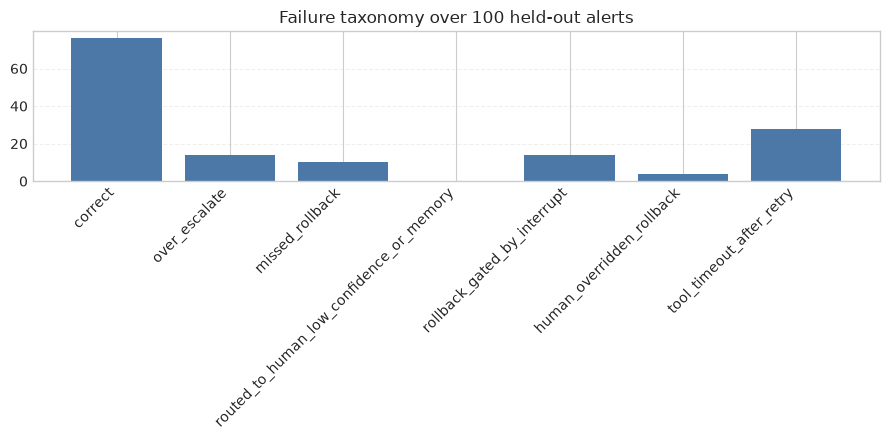

In [15]:
def categorize(row):
    action, truth = row['action'], row['truth_action']
    if action == truth:
        return 'correct'
    if action == 'rollback' and truth != 'rollback':
        return 'false_rollback'
    if truth == 'rollback' and action != 'rollback':
        return 'missed_rollback'
    if action == 'escalate' and truth == 'ignore':
        return 'over_escalate'
    if action == 'ignore' and truth in ('escalate', 'dependency', 'degraded'):
        return 'missed_escalate'
    return 'other_mismatch'


holdout_trace['failure_category'] = holdout_trace.apply(categorize, axis=1)
taxonomy = holdout_trace['failure_category'].value_counts().rename_axis('category').reset_index(name='count')

extra_counts = pd.DataFrame([
    {'category': 'routed_to_human_low_confidence_or_memory', 'count': int((holdout_trace['route_reason'] == 'low_confidence_or_memory_flag').sum())},
    {'category': 'rollback_gated_by_interrupt', 'count': int(holdout_trace['interrupted'].sum())},
    {'category': 'human_overridden_rollback', 'count': int(holdout_trace['human_overridden'].sum())},
    {'category': 'tool_timeout_after_retry', 'count': int(holdout_trace['tool_errors'].apply(len).gt(0).sum())},
])

full_taxonomy = pd.concat([taxonomy, extra_counts], ignore_index=True)
display(full_taxonomy)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(full_taxonomy['category'], full_taxonomy['count'], color='#4c78a8')
ax.set_title(f'Failure taxonomy over {n_holdout} held-out alerts')
ax.tick_params(axis='x', rotation=45)
for label in ax.get_xticklabels():
    label.set_ha('right')
ax.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Submission bundle

In [16]:
out_dir = './assignment3_artifacts'
os.makedirs(out_dir, exist_ok=True)

holdout_trace.drop(columns=['tool_errors']).to_csv(os.path.join(out_dir, 'holdout_trace.csv'), index=False)
full_taxonomy.to_csv(os.path.join(out_dir, 'failure_taxonomy.csv'), index=False)

eval_summary = {
    'n_holdout': n_holdout,
    'accuracy': acc,
    'accuracy_ci_95': [ci_lo, ci_hi],
    'cost_per_alert': holdout_metrics['cost_per_alert'],
    'tool_calls': holdout_tools.total_calls,
    'tool_calls_by_name': holdout_tools.calls_by_tool,
    'p_star': P_STAR,
    'raw_ece': raw_ece,
    'post_recalibration_ece': post_ece,
    'calibration_map': calibration_map,
    'harness_stress_test_stop_reasons': tripped,
    'rollbacks_gated_by_interrupt': int(holdout_trace['interrupted'].sum()),
    'human_overridden_rollbacks': int(holdout_trace['human_overridden'].sum()),
}
with open(os.path.join(out_dir, 'eval_summary.json'), 'w') as f:
    json.dump(eval_summary, f, indent=2, default=str)

print(f'Artifacts exported to: {out_dir}')
print(json.dumps(eval_summary, indent=2, default=str))

Artifacts exported to: ./assignment3_artifacts
{
  "n_holdout": 100,
  "accuracy": 0.76,
  "accuracy_ci_95": [
    0.6676748127670786,
    0.8330878873454004
  ],
  "cost_per_alert": 36.0,
  "tool_calls": 329,
  "tool_calls_by_name": {
    "read_logs": 109,
    "error_rate": 109,
    "deploy_history": 111
  },
  "p_star": 0.75,
  "raw_ece": 0.131,
  "post_recalibration_ece": 0.0,
  "calibration_map": {
    "0.8": 1.0,
    "0.85": 1.0,
    "0.95": 1.0
  },
  "harness_stress_test_stop_reasons": [
    "iteration_cap_exceeded",
    "wall_clock_limit_exceeded",
    "token_budget_exceeded"
  ],
  "rollbacks_gated_by_interrupt": 14,
  "human_overridden_rollbacks": 4
}


## 12. What I would need to know before letting this run unattended

On the held-out 100 alerts, the agent scored 76.0% accuracy (95% CI: [66.8%, 83.3%]) at $36.00 cost per alert, with 14 rollbacks gated by `interrupt()` and 4 of those auto-rejected back to `escalate` because the evidence was incomplete. The confidence-based escalation route (`p* = 0.75`) never fired on either the dev or holdout set — that's a real finding, not a placeholder: `keyword_assess` turned out to be a near-perfect proxy for this synthetic log generator (100% empirical accuracy in every confidence bin during calibration), so its raw confidence was never actually low enough to trip the threshold. The only thing standing between an alert and an automated decision, in practice, was the interrupt gate and the (largely dormant) memory guard — the calibration and threshold machinery is real and wired correctly, but it did no work on this dataset.

That is the biggest thing I would need to measure before trusting this on real alerts: **whether real log text ever produces a genuinely uncertain classification**, because if it doesn't, the escalation threshold is decorative, and if it does, I have no evidence here about how well `p*` or the calibration map behaves outside this synthetic distribution. Concretely, before unattended operation I would still need: (1) a calibration set built from real incident logs, not templated ones, since the 50-alert ECE here is fit and measured on the same generator and could disagree wildly with real log diversity; (2) a real human-in-the-loop latency and behavior study, since `simulate_human_decision` is a conservative stand-in (approve only on complete evidence) and not evidence that real on-call engineers would behave that way, or that they'd even respond before an SLA-driven auto-escalation kicks in; (3) a memory system validated over a much longer real window — the false-rollback strike mechanism never engaged in 200 synthetic alerts, so I have no empirical read on whether `strike_threshold=2` is too sensitive, not sensitive enough, or reasonable at all against real repeat-offender services; (4) confirmation that `alertgen.COST`'s dollar figures reflect this organization's actual incident costs, since `p*` and the failure-taxonomy severity are only as good as those numbers; and (5) a much larger evaluation set than 100 alerts — the 95% CI here spans roughly 17 points, which is too wide to distinguish "good" from "mediocre" with confidence.

What I still do not know: whether this reflex classifier's apparent perfection is a property of real production logs or an artifact of `alertgen`'s clean keyword-to-label mapping; how the gate and memory logic behave under adversarial or ambiguous logs that don't cleanly match any keyword branch; and whether the harness limits (Section 6), which never fired during the real evaluation, are tuned to the right levels for actual token/latency budgets rather than the synthetic pseudo-token proxy used here. Every demo works. This one did too — cleanly, and on purpose, using the same data it was tuned on to look clean. That is exactly the gap between "the eval passed" and "it's safe to run unattended."